# 課題7 Sentence Generation: Image Captioning

画像から文章を生成する caption generation を体験します。COCO dataset はコピーせず、`data/COCO` から `/export/data/dataset/COCO` へのシンボリックリンクを作って使います。

古典的には CNN で画像特徴を抽出し、LSTM などの言語モデルで文章を生成します。この notebook では、オープンソースの pretrained vision-language model である BLIP を使い、学習なしで COCO 画像の caption を生成します。

In [1]:
from pathlib import Path
import json
import os
import random
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt

# 課題フォルダと保存先。
BASE_DIR = Path('/export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2')
TASK_DIR = BASE_DIR / 'kadai7-caption_generation'
OUT_DIR = TASK_DIR / 'out'
MODEL_DIR = TASK_DIR / 'model'
DATA_DIR = BASE_DIR / 'data'
LAB_COCO_DIR = Path('/export/data/dataset/COCO')
COCO_LINK = DATA_DIR / 'COCO'

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# GPUは1枚だけ使う。
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## COCO symlink の作成

課題文の指示に従い、COCO をコピーせずに `ln -s /export/data/dataset/COCO data/COCO` 相当のシンボリックリンクを作ります。すでに存在する場合はそのまま使います。

In [2]:
if not COCO_LINK.exists():
    if not LAB_COCO_DIR.exists():
        raise FileNotFoundError(f'COCO dataset not found: {LAB_COCO_DIR}')
    os.symlink(LAB_COCO_DIR, COCO_LINK, target_is_directory=True)

print('COCO link:', COCO_LINK)
print('COCO target exists:', COCO_LINK.exists())

COCO link: /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO
COCO target exists: True


## COCO 画像を選ぶ

annotation が使える場合、`person`, `bus`, `airplane`, `dog`, `cat` などが写っている画像を選びます。caption generation の結果が分かりやすいように、複数カテゴリから最大5枚を選びます。

In [3]:
def find_annotation_file(coco_dir):
    candidates = [
        coco_dir / 'annotations' / 'instances_val2014.json',
        coco_dir / 'annotations' / 'instances_train2014.json',
        coco_dir / 'annotations.org' / 'instances_val2014.json',
        coco_dir / 'annotations.org' / 'instances_train2014.json',
    ]
    for path in candidates:
        if path.exists():
            return path
    return None

def image_path_from_file_name(coco_dir, file_name):
    for split in ['val2014', 'train2014', 'test2014']:
        path = coco_dir / split / file_name
        if path.exists():
            return path
    matches = list(coco_dir.glob(f'**/{file_name}'))
    if matches:
        return matches[0]
    raise FileNotFoundError(file_name)

def select_coco_images(coco_dir, labels=('person', 'bus', 'airplane', 'dog', 'cat')):
    ann_path = find_annotation_file(coco_dir)
    selected = []
    used_image_ids = set()
    if ann_path is not None:
        print('annotation:', ann_path)
        data = json.loads(ann_path.read_text())
        cat_name_to_id = {c['name']: c['id'] for c in data['categories']}
        image_id_to_file = {img['id']: img['file_name'] for img in data['images']}
        for label in labels:
            cat_id = cat_name_to_id.get(label)
            if cat_id is None:
                continue
            for ann in data['annotations']:
                if ann['category_id'] == cat_id and ann.get('area', 0) > 3000 and ann['image_id'] not in used_image_ids:
                    file_name = image_id_to_file[ann['image_id']]
                    selected.append({'label': label, 'path': image_path_from_file_name(coco_dir, file_name)})
                    used_image_ids.add(ann['image_id'])
                    break

    if len(selected) < 3:
        print('annotation based selection failed. fallback to image files.')
        paths = []
        for split in ['val2014', 'train2014']:
            root = coco_dir / split
            if root.exists():
                paths.extend(sorted(root.glob('*.jpg')))
        selected = [{'label': f'image_{i}', 'path': p} for i, p in enumerate(paths[:5])]
    return selected[:5]

selected = select_coco_images(COCO_LINK)
images = []
for item in selected:
    img = Image.open(item['path']).convert('RGB')
    images.append({**item, 'image': img})
    print(item['label'], item['path'])

annotation: /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/annotations/instances_val2014.json
person /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/val2014/COCO_val2014_000000537548.jpg
bus /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/val2014/COCO_val2014_000000017207.jpg
airplane /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/val2014/COCO_val2014_000000504811.jpg
dog /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/val2014/COCO_val2014_000000016164.jpg
cat /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/data/COCO/val2014/COCO_val2014_000000157807.jpg


## BLIP model の読み込み

外部ネットワークが使えない環境を考え、まず `model/blip-image-captioning-base/` に手動配置したモデルを探します。モデルを手動で置いていない場合だけ、`ALLOW_DOWNLOAD=True` にすると Hugging Face から取得します。

In [4]:
# 学内ネットワーク経由の場合はプロキシを設定
os.environ["http_proxy"]  = "http://proxy.uec.ac.jp:8080/"
os.environ["https_proxy"] = "http://proxy.uec.ac.jp:8080/"

# IPv6 を無効化（接続問題の回避）
os.environ["HF_HUB_DISABLE_IPV6"] = "1"

In [6]:
from huggingface_hub import login

# Hugging Face アクセストークンでログイン
login("")

In [9]:
ALLOW_DOWNLOAD = True

LOCAL_BLIP_DIR = MODEL_DIR / "blip-image-captioning-base"
HF_CACHE_DIR = MODEL_DIR / "hf_cache"
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

from transformers import BlipImageProcessor, BlipForConditionalGeneration, AutoTokenizer

if LOCAL_BLIP_DIR.exists():
    model_name_or_path = str(LOCAL_BLIP_DIR)
    local_only = True
else:
    model_name_or_path = "Salesforce/blip-image-captioning-base"
    local_only = not ALLOW_DOWNLOAD

print("BLIP model:", model_name_or_path)

image_processor = BlipImageProcessor.from_pretrained(
    model_name_or_path,
    local_files_only=local_only,
    cache_dir=HF_CACHE_DIR,
)

tokenizer = AutoTokenizer.from_pretrained(
    model_name_or_path,
    local_files_only=local_only,
    cache_dir=HF_CACHE_DIR,
)

caption_model = BlipForConditionalGeneration.from_pretrained(
    model_name_or_path,
    local_files_only=local_only,
    cache_dir=HF_CACHE_DIR,
).to(device).eval()

BLIP model: Salesforce/blip-image-captioning-base


Loading weights: 100%|██████████| 473/473 [00:00<00:00, 27689.62it/s]
/home/yanai-lab/oyundari/miniconda3/envs/sd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


## Caption generation

各 COCO 画像を BLIP に入力し、caption を生成します。`max_new_tokens` で生成する文の長さを制限します。

In [10]:
caption_results = []

for item in images:
    pixel_values = image_processor(
        images=item["image"],
        return_tensors="pt"
    ).pixel_values.to(device)

    with torch.no_grad():
        output_ids = caption_model.generate(
            pixel_values=pixel_values,
            max_new_tokens=30,
        )

    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    caption_results.append({**item, "caption": caption})
    print(item["label"], "->", caption)

person -> a man riding a motorcycle down a street
bus -> a bus on the road
airplane -> a plane flying over a church in a town
dog -> a dog laying in a dirty bathroom
cat -> a cat standing on a toilet


## 結果保存

画像と生成 caption を1枚の図にまとめて保存します。レポートにそのまま貼れるよう、caption の一覧も JSON / Markdown で保存します。

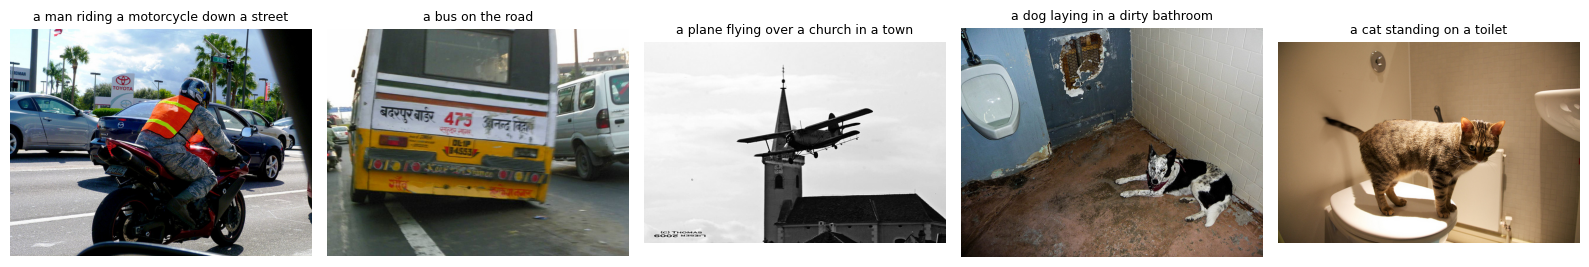

saved: /export/space0/oyundari/jupyter/notebook/kadai4/dnn_kadai2/kadai7-caption_generation/out/caption_generation_results.png


In [11]:
cols = len(caption_results)
plt.figure(figsize=(cols * 3.2, 4.2))
for i, item in enumerate(caption_results):
    plt.subplot(1, cols, i + 1)
    plt.imshow(item['image'])
    plt.axis('off')
    plt.title(item['caption'], fontsize=9, wrap=True)
plt.tight_layout()
plt.savefig(OUT_DIR / 'caption_generation_results.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

summary = [{'label': r['label'], 'image_path': str(r['path']), 'caption': r['caption']} for r in caption_results]
(OUT_DIR / 'caption_results.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

md = ['# Caption Generation Results', '']
for r in summary:
    md.append(f"- `{r['label']}`: {r['caption']}  ")
    md.append(f"  - image: `{r['image_path']}`")
(OUT_DIR / 'caption_results.md').write_text('\n'.join(md), encoding='utf-8')
print('saved:', OUT_DIR / 'caption_generation_results.png')